In [13]:
##import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y dataset')

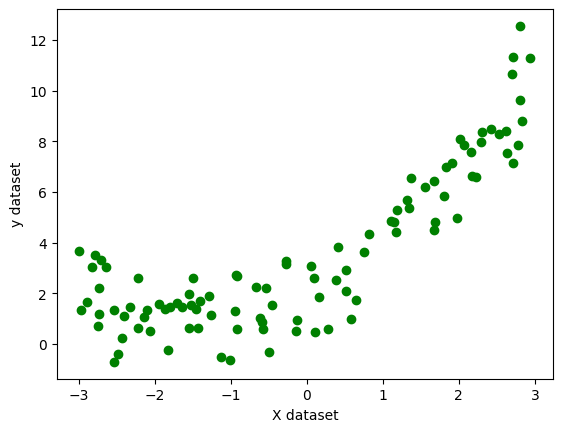

In [14]:
X = 6 * np.random.rand(100,1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)

plt.scatter(X, y, color = "g")
plt.xlabel("X dataset")
plt.ylabel("y dataset")
# quadratic eq used - y = 0.5 * X**2 + 1.5*X + 2 + outliers

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
## First lets try with simple linear regression
from sklearn.linear_model import  LinearRegression
regression_1 = LinearRegression()


In [17]:
regression_1.fit(X_train, y_train)


LinearRegression()

In [18]:
y_pred_1 = regression_1.predict(X_test)

In [19]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_test))
print(score)            

0.7288294203905042


Text(0, 0.5, 'y Dataset')

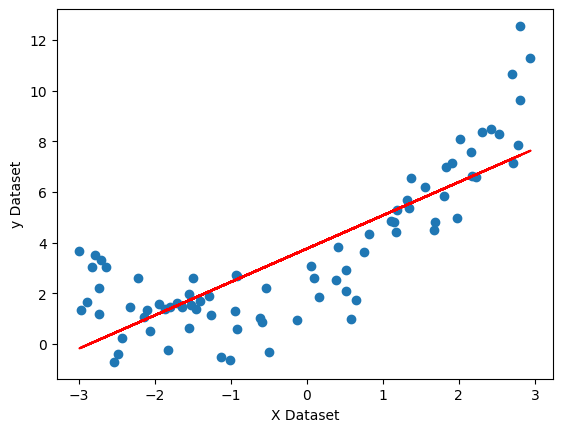

In [20]:
#Let's vizualize the results
plt.plot(X_train , regression_1.predict(X_train), color = "r")
plt.scatter(X_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("y Dataset")

In [21]:
### Now let's try polynomial regression

from sklearn.preprocessing import PolynomialFeatures


In [22]:
poly = PolynomialFeatures(degree = 2 , include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
X_train_poly

array([[ 1.00000000e+00,  5.10524826e-01,  2.60635598e-01],
       [ 1.00000000e+00, -2.14390091e+00,  4.59631113e+00],
       [ 1.00000000e+00,  1.97164956e+00,  3.88740198e+00],
       [ 1.00000000e+00,  2.70089443e+00,  7.29483073e+00],
       [ 1.00000000e+00, -9.18754899e-01,  8.44110565e-01],
       [ 1.00000000e+00, -1.50385059e+00,  2.26156659e+00],
       [ 1.00000000e+00, -1.82455106e+00,  3.32898656e+00],
       [ 1.00000000e+00, -2.89893499e+00,  8.40382407e+00],
       [ 1.00000000e+00,  2.94122280e+00,  8.65079155e+00],
       [ 1.00000000e+00, -1.70799540e+00,  2.91724828e+00],
       [ 1.00000000e+00, -1.86023006e+00,  3.46045589e+00],
       [ 1.00000000e+00,  1.83033005e+00,  3.35010809e+00],
       [ 1.00000000e+00, -9.28737272e-01,  8.62552921e-01],
       [ 1.00000000e+00, -2.99191257e+00,  8.95154083e+00],
       [ 1.00000000e+00,  2.01351547e+00,  4.05424453e+00],
       [ 1.00000000e+00,  2.17987398e+00,  4.75185056e+00],
       [ 1.00000000e+00, -2.82941323e+00

In [24]:
X_test_poly

array([[ 1.        ,  0.10317987,  0.01064609],
       [ 1.        ,  2.07359273,  4.29978682],
       [ 1.        , -0.57093397,  0.3259656 ],
       [ 1.        ,  2.61965331,  6.86258346],
       [ 1.        , -0.27986078,  0.07832206],
       [ 1.        , -2.75111466,  7.56863185],
       [ 1.        , -0.13952498,  0.01946722],
       [ 1.        ,  1.67716736,  2.81289034],
       [ 1.        , -2.53301407,  6.41616028],
       [ 1.        , -0.66246521,  0.43886016],
       [ 1.        , -0.27909866,  0.07789606],
       [ 1.        ,  2.29630232,  5.27300433],
       [ 1.        ,  0.27282699,  0.07443456],
       [ 1.        ,  2.62754732,  6.9040049 ],
       [ 1.        ,  2.70974494,  7.34271764],
       [ 1.        , -1.43597434,  2.06202232],
       [ 1.        ,  2.83486085,  8.03643606],
       [ 1.        , -0.45288587,  0.20510561],
       [ 1.        , -2.22184044,  4.93657493],
       [ 1.        , -2.40119968,  5.7657599 ]])

In [25]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)  

0.894918549296114


In [26]:
print(regression.coef_)

[[0.         1.39477322 0.50107218]]


In [27]:
print(regression.intercept_)

[2.04877646]


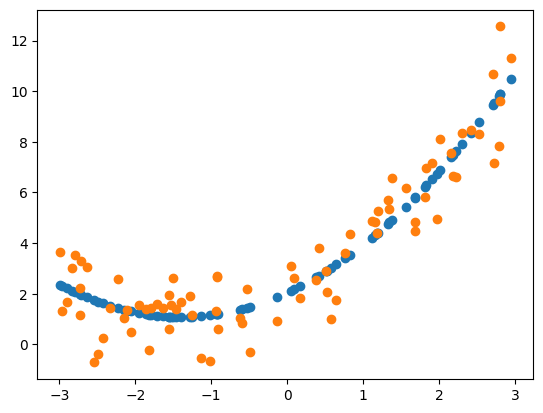

In [28]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [29]:
# -----------------Pipeline Concept ------------------#


In [30]:
from sklearn.pipeline import Pipeline

In [31]:
def poly_regression(degree):
    X_new = np.linspace(-3 , 3 , 200).reshape(200,1)

    poly_features = PloynomialFeatures(degree = degree, include_bias = True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features",poly_features),
        ("lin_reg", lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)


    # plotting prdiction line

    plt.plot(X_new , y_pred_new , 'r' , lable = "Degree" + str(degree), linewidth = 3)
    plt.plot(X_train , y_train , "b.",linewidth = 3)
    plt.plot(X_test , y_test , 'g' , linewidth = 3)
    plt.legend(loc = "upper left")
    plt.xlabel("X")
    plt,ylable("y  ")
    plt.axis([-4,4,0,10])
    plt.show


In [33]:
poly_regression(2)

NameError: name 'PloynomialFeatures' is not defined